The purpose of this project is to train a model that predicts the popularity of a song.

This could be extremely useful in the modern age where trends seem to happen really quickly.
With social media platforms learning from these trends, it would seem beneficial to predict
how well a song will do and under what circumstances.

This dataset comes from the abracadabra project:
https://github.com/DevDope/Abracadabra

Some predictions of my own:
Hypothesis 1: Older popular songs will have a lower BPM compared to newer popular songs.

Hypothesis 2: Newer songs will score higher in the danceability feature, 
while older popular songs will vary more in emotion 

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

import matplotlib.pyplot as plt
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/900k-spotify/spotify_dataset.csv
/kaggle/input/900k-spotify/900k Definitive Spotify Dataset.json


In [2]:
#load data
df = pd.read_csv('/kaggle/input/900k-spotify/spotify_dataset.csv')

print("Columns in the dataset:")
print(df.columns.tolist())


Columns in the dataset:
['Artist(s)', 'song', 'text', 'Length', 'emotion', 'Genre', 'Album', 'Release Date', 'Key', 'Tempo', 'Loudness (db)', 'Time signature', 'Explicit', 'Popularity', 'Energy', 'Danceability', 'Positiveness', 'Speechiness', 'Liveness', 'Acousticness', 'Instrumentalness', 'Good for Party', 'Good for Work/Study', 'Good for Relaxation/Meditation', 'Good for Exercise', 'Good for Running', 'Good for Yoga/Stretching', 'Good for Driving', 'Good for Social Gatherings', 'Good for Morning Routine', 'Similar Artist 1', 'Similar Song 1', 'Similarity Score 1', 'Similar Artist 2', 'Similar Song 2', 'Similarity Score 2', 'Similar Artist 3', 'Similar Song 3', 'Similarity Score 3']


In [3]:
df.head(10)

,Artist(s),song,text,Length,emotion,Genre,Album,Release Date,Key,Tempo,...,Good for Morning Routine,Similar Artist 1,Similar Song 1,Similarity Score 1,Similar Artist 2,Similar Song 2,Similarity Score 2,Similar Artist 3,Similar Song 3,Similarity Score 3
0,!!!,Even When the Waters Cold,Friends told her she was better off at the bot...,03:47,sadness,hip hop,Thr!!!er,2013-04-29,D min,0.437870,...,0,Corey Smith,If I Could Do It Again,0.986061,Toby Keith,Drinks After Work,0.983719,Space,Neighbourhood,0.983236
1,!!!,One Girl / One Boy,"Well I heard it, playing soft From a drunken b...",04:03,sadness,hip hop,Thr!!!er,2013-04-29,A# min,0.508876,...,0,Hiroyuki Sawano,BRE@TH//LESS,0.995409,When In Rome,Heaven Knows,0.990905,Justice Crew,Everybody,0.984483
2,!!!,Pardon My Freedom,"Oh my god, did I just say that out loud? Shoul...",05:51,joy,hip hop,Louden Up Now,2004-06-08,A Maj,0.532544,...,0,Ricky Dillard,More Abundantly Medley Live,0.993176,Juliet,Avalon,0.965147,The Jacksons,Lovely One,0.956752
3,!!!,Ooo,[Verse 1] Remember when I called you on the te...,03:44,joy,hip hop,As If,2015-10-16,A min,0.538462,...,0,Eric Clapton,Man Overboard,0.992749,Roxette,Don't Believe In Accidents,0.991494,Tiwa Savage,My Darlin,0.990381
4,!!!,Freedom 15,[Verse 1] Calling me like I got something to s...,06:00,joy,hip hop,As If,2015-10-16,F min,0.544379,...,0,Cibo Matto,Lint Of Love,0.981610,Barrington Levy,Better Than Gold,0.981524,Freestyle,Its Automatic,0.981415
5,!!!,All U Writers,All you writers Get out your pens and write Al...,05:22,love,hip hop,All U Writers / Gonna Guetta Stomp,2015-04-27,B min,0.538462,...,0,Wish & Fonda Rae,Touch Me All Night Long,0.980839,Gary Numan,War Songs,0.980527,Little Dragon,Forever,0.980209
6,!!!,Serbia Drums,[Verse 1] We've known working in obscurity and...,03:39,sadness,hip hop,Wallop,2019-08-30,E min,0.431953,...,0,Talking Heads,Ruby Dear,0.980781,Hanson,Something Going Round,0.979205,"Hoodie Allen,Jared Evan",Same As Before,0.978977
7,!!!,Must Be the Moon,"One drink, two drinks, three drinks, four She ...",05:57,joy,hip hop,Myth Takes,2007-03-05,G Maj,0.526627,...,0,"Crystal Waters,Steve ""Silk"" Hurley",Makin Happy,0.985045,Marvin Gaye,Sanctified Lady,0.974169,Ready For The World,Digital Display,0.973508
8,!!!,Slyd,"No, that's weird Slyd, slyd, slyd, you like th...",04:14,surprise,hip hop,Thr!!!er,2013-04-29,C Maj,0.526627,...,0,"Moon Boots,Fiora",I Want Your Attention,0.992940,"Rhombus,Tiki Taane,MC Antsman,Imon Starr",Seen It All Beast Mix,0.991243,"Craig Reever,Easton",Special about You,0.989623
9,!!!,Hello? Is This Thing On?,Sometimes you don't say nothing 'cause you got...,07:33,sadness,hip hop,Louden Up Now,2004-06-08,G Maj,0.550296,...,1,Midnight Star,Operator,0.985598,"Boris Dlugosch,Róisín Murphy,Ricky Mattioli",Never Enough,0.979075,YACHT,Miles Miles,0.978798


After careful consideration, there are some columns that would most likely not work towards my goal of finding the popularity of a song, such as: 

* artist name (song popularity should be independent of artist)
* song name (song popularity should be independent of name, we're only interested in the audible parts for now)
* album name (song popularity should be independent of album name)

more complex columns to drop that might get tested later with a different model:
* text
* similar artist #1, #2, #3
* similar song #1, #2, #3
* similarity score #1, #2, #3

In [4]:
columns_to_drop = ['Artist(s)', 'song', 'text', 'Album', 'Similar Artist 1', 
                   'Similar Song 1', 'Similarity Score 1', 'Similar Artist 2', 
                   'Similar Song 2', 'Similarity Score 2', 'Similar Artist 3', 
                   'Similar Song 3', 'Similarity Score 3']

df = df.drop(columns=columns_to_drop)
print(df.columns.tolist())

['Length', 'emotion', 'Genre', 'Release Date', 'Key', 'Tempo', 'Loudness (db)', 'Time signature', 'Explicit', 'Popularity', 'Energy', 'Danceability', 'Positiveness', 'Speechiness', 'Liveness', 'Acousticness', 'Instrumentalness', 'Good for Party', 'Good for Work/Study', 'Good for Relaxation/Meditation', 'Good for Exercise', 'Good for Running', 'Good for Yoga/Stretching', 'Good for Driving', 'Good for Social Gatherings', 'Good for Morning Routine']


In [5]:
print(df.dtypes)

Length                             object
emotion                            object
Genre                              object
Release Date                       object
Key                                object
Tempo                             float64
Loudness (db)                     float64
Time signature                     object
Explicit                           object
Popularity                          int64
Energy                              int64
Danceability                        int64
Positiveness                        int64
Speechiness                         int64
Liveness                            int64
Acousticness                        int64
Instrumentalness                    int64
Good for Party                      int64
Good for Work/Study                 int64
Good for Relaxation/Meditation      int64
Good for Exercise                   int64
Good for Running                    int64
Good for Yoga/Stretching            int64
Good for Driving                  

In [6]:
popular_song_count = (df['Popularity'] > 70).sum()
total_songs = len(df)
percent_popular = popular_song_count / total_songs * 100
print(popular_song_count)
df['Popularity'].value_counts(bins=[0, 20, 40, 60, 80, 100])
print(f"the percent of picking a popular song is: ", {percent_popular})


13845
the percent of picking a popular song is:  {2.7798302185313983}


After analyzing the data types for each column, I can tell there will be certain format changes.

These are the main things I will tackle now:

1. length (object) MM:SS should be total seconds (numeric)

2. emotion (object) is one string so I can use one-hot encoding (numeric) to turn it into numerical data the tree can use to split

3. genre (object) a song can have multiple genres, so instead we can use a multi label binary feature set

4. release date (object) this is an interesting fork in the road. 
* I can use the **song age**, which will help capture the recency.* 

* I could also use the **release year**, which could capture historical context (e.g. 2020

* Another interesting metric would be **release month**, to capture seasonal patterns.

* I might use release day (Mon, Wed,...) later on, but nowadays music seems to be released on Friday, so the data might be skewed for more recently released songs.

* Another side note is that by adding these features in a random forest model, the collinearity between them is mitigated because they don't care about coefficients, and also picks the best feature to split on, and also because of random feature sampling.

5. key (object) is also one string in value, so I'll be using one-hot encoding

6. Time Signature (object 4/4, 5/4, 3/4, 1/4) could be converted into a number since the only the numerator is different, but there is no ordinal meaning, so I'll also use one-hot encoding for this.

7. Explicit is a boolean value (yes, no) so I will convert it to 0 and 1

In [7]:
#change length to length_secs
def time_to_seconds(length_str):
    parts = length_str.split(':')
    parts = [int(p) for p in parts]
    if len(parts) == 2:
        return parts[0] * 60 + parts[1]
    elif len(parts) == 3:
        return parts[0] * 3600 + parts[1] * 60 + parts[2]
    return None

df['Length_sec'] = df['Length'].apply(time_to_seconds)
df.drop(columns='Length', inplace=True)

In [8]:
#change emotion to one-hot encoding
emotion_dummies = pd.get_dummies(df['emotion'], prefix='emotion', dtype=int)

df = pd.concat([df, emotion_dummies], axis=1)
df.drop('emotion', axis=1, inplace=True)

On the cell below we can see that there are overall genres as well as subgenres e.g. metal, black metal, death metal etc...

More importantly, there are repeated genres such as hip hop and hip-hop. 

In order to not get rid of potentially useful data from subgenres, I'll keep them and just condense the similarly named features.

Features to merge:
* hip hop and hip-hop
* indie and indie-rock
* punk and punk rock
* electro and electronic
* alternative and alternative rock

In [9]:
#multi label binary
genre_mapping = {
    'hip-hop': 'hip hop',
    'indie rock': 'indie',
    'punk rock': 'punk',
    'electro': 'electronic',
    'alternative rock': 'alternative',
}

df['genre_list'] = df['Genre'].str.split(',\s*')

#apply genre mapping
df['genre_list'] = df['genre_list'].apply(
    lambda genres: [genre_mapping.get(g.strip().lower(), g.strip().lower()) for g in genres]
)

all_genres = [genre for sublist in df['genre_list'] for genre in sublist]

unique_genres = sorted(set(all_genres))

print(f"Total unique genres: {len(unique_genres)}")

#binary features
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
genre_dummies = pd.DataFrame(mlb.fit_transform(df['genre_list']),
                              columns=mlb.classes_,
                              index=df.index)

#combine
df = pd.concat([df, genre_dummies], axis=1)
df.drop(['Genre', 'genre_list'], axis=1, inplace=True)
# print(df.dtypes)
print("Unique genres:")
for genre in unique_genres:
    print(repr(genre)) 

Total unique genres: 83
Unique genres:
'acoustic'
'alt-country'
'alternative'
'ambient'
'black metal'
'blues'
'britpop'
'chillout'
'chillwave'
'christian'
'classic rock'
'classical'
'cloud rap'
'comedy'
'country'
'dance'
'dancehall'
'death metal'
'deathcore'
'disco'
'doom metal'
'dream pop'
'drum and bass'
'dub'
'dubstep'
'electronic'
'electropop'
'emo'
'emo rap'
'experimental'
'folk'
'funk'
'garage rock'
'gospel'
'grime'
'grunge'
'hard rock'
'hardcore'
'heavy metal'
'hip hop'
'house'
'indie'
'indie pop'
'industrial'
'j-pop'
'jazz'
'k-pop'
'latin'
'lo-fi'
'math rock'
'melodic death metal'
'metal'
'metalcore'
'new wave'
'nu metal'
'pop'
'pop punk'
'pop rock'
'post-hardcore'
'post-punk'
'power metal'
'progressive metal'
'progressive rock'
'psychedelic'
'psychedelic rock'
'punk'
'rap'
'reggae'
'reggaeton'
'rnb'
'rock'
'screamo'
'shoegaze'
'soul'
'soundtrack'
'swing'
'synthpop'
'techno'
'thrash metal'
'trance'
'trap'
'trip-hop'
'worship'


In the code block below I'm treating the rows with null dates. Because the data sample is about 400k~ rows, and there are about 140k~ that have no dates, I'm choosing to fill in the values with -1.

This placeholder value will let me keep these points, seeing as its about a third of my dataset.

In [10]:
print("Missing raw release dates before cleaning:", df['Release Date'].isnull().sum())

print(df['Release Date'].dropna().drop_duplicates().sample(100, random_state=42))

import re
import pandas as pd
from datetime import datetime

df['Release Date Raw'] = df['Release Date']

def clean_date(date_str):
    if pd.isnull(date_str):
        return None
    cleaned = re.sub(r'(\d+)(st|nd|rd|th)', r'\1', str(date_str))  # Remove suffixes
    return cleaned.strip()

df['Release Date'] = df['Release Date'].apply(clean_date)

df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')

current_year = datetime.today().year

df['song_age'] = current_year - df['Release Date'].dt.year
df['release_year'] = df['Release Date'].dt.year
df['release_month'] = df['Release Date'].dt.month


df[['song_age', 'release_year', 'release_month']] = df[[
    'song_age', 'release_year', 'release_month'
]].fillna(-1)

df.drop(columns=['Release Date', 'Release Date Raw'], inplace=True)

print(df[['song_age', 'release_year', 'release_month']].head())


Missing raw release dates before cleaning: 147683
441473    1966-02-18
24999     2014-02-12
177080    2001-01-15
30225     2013-11-25
45162     1991-10-29
             ...    
364572    2010-11-14
348790    1979-04-29
55694     1996-03-19
4404      2012-09-12
249910    1977-07-05
Name: Release Date, Length: 100, dtype: object
   song_age  release_year  release_month
0      12.0        2013.0            4.0
1      12.0        2013.0            4.0
2      21.0        2004.0            6.0
3      10.0        2015.0           10.0
4      10.0        2015.0           10.0


In [11]:
#key
key_dummies = pd.get_dummies(df['Key'], prefix='key', dtype=int)
df = pd.concat([df, key_dummies], axis=1)

df.drop('Key', axis=1, inplace=True)



In [12]:
#time signature
df['time_signature'] = df['Time signature'].str.strip()

ts_dummies = pd.get_dummies(df['time_signature'], prefix='ts', dtype=int)
df = pd.concat([df, ts_dummies], axis=1)

df.drop(['Time signature', 'time_signature'], axis=1, inplace=True)

In [13]:
#explicit
df['explicit'] = df['Explicit'].str.lower().map({'yes': 1, 'no': 0})

# Drop the original column
df.drop('Explicit', axis=1, inplace=True)

In [14]:
#check that all types are good
pd.set_option('display.max_columns', None)      # show all columns
pd.set_option('display.max_rows', None)         # show all rows (optional)
pd.set_option('display.max_seq_items', None)    # show full dtype series


print(df.dtypes)

Tempo                             float64
Loudness (db)                     float64
Popularity                          int64
Energy                              int64
Danceability                        int64
Positiveness                        int64
Speechiness                         int64
Liveness                            int64
Acousticness                        int64
Instrumentalness                    int64
Good for Party                      int64
Good for Work/Study                 int64
Good for Relaxation/Meditation      int64
Good for Exercise                   int64
Good for Running                    int64
Good for Yoga/Stretching            int64
Good for Driving                    int64
Good for Social Gatherings          int64
Good for Morning Routine            int64
Length_sec                          int64
emotion_Love                        int64
emotion_True                        int64
emotion_anger                       int64
emotion_angry                     

In [15]:
#check that there are no null values
pd.set_option('display.max_columns', None)     
pd.set_option('display.max_rows', None)         
pd.set_option('display.max_seq_items', None)   
print(df.isnull().sum())

Tempo                             0
Loudness (db)                     0
Popularity                        0
Energy                            0
Danceability                      0
Positiveness                      0
Speechiness                       0
Liveness                          0
Acousticness                      0
Instrumentalness                  0
Good for Party                    0
Good for Work/Study               0
Good for Relaxation/Meditation    0
Good for Exercise                 0
Good for Running                  0
Good for Yoga/Stretching          0
Good for Driving                  0
Good for Social Gatherings        0
Good for Morning Routine          0
Length_sec                        0
emotion_Love                      0
emotion_True                      0
emotion_anger                     0
emotion_angry                     0
emotion_confusion                 0
emotion_fear                      0
emotion_interest                  0
emotion_joy                 

Before we start testing the data, let's take a look at how each feature is correlated to popularity thus far.

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


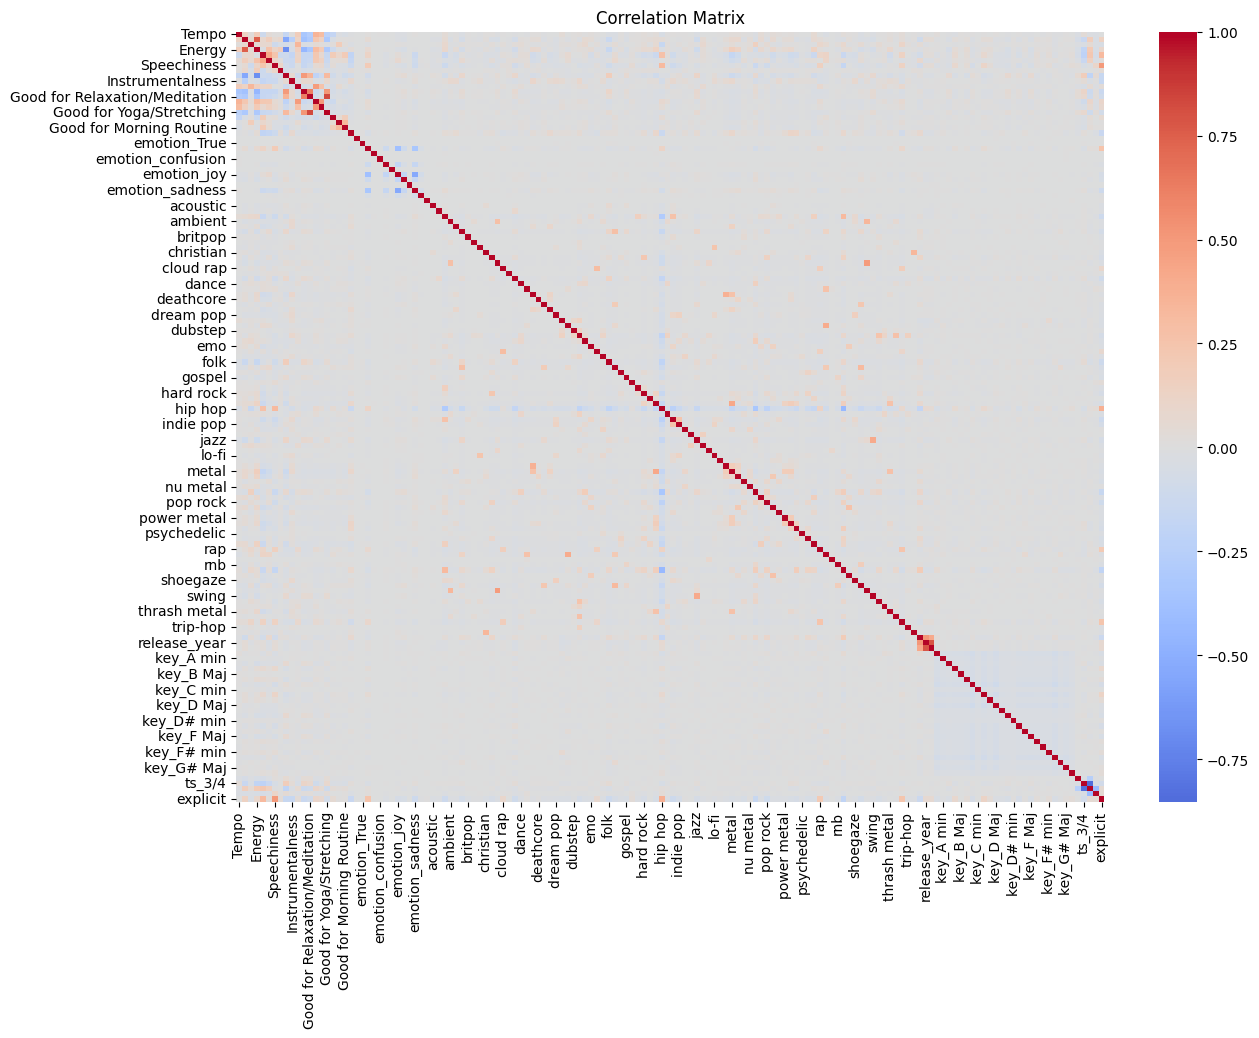

In [16]:
# Clean data for plot, make sure they're all numbers
df_corr = df.select_dtypes(include='number')
#make sure results are not all the same
df_corr = df_corr.loc[:, df_corr.nunique() > 1]

corr = df_corr.corr()

# Plot
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title("Correlation Matrix")
plt.show()

In [17]:
# drop self-correlation
target_corr = corr['Popularity'].drop('Popularity')  

# Sort by absolute value
top_corr = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)

# Display top N
print("Top features correlated with Popularity:")
print(top_corr.head(10))


Top features correlated with Popularity:
Good for Party                0.335947
Good for Social Gatherings    0.189950
hip hop                      -0.151859
pop                           0.149549
trap                          0.114099
Speechiness                  -0.110863
rap                           0.091254
rock                          0.085467
alternative                   0.084390
Loudness (db)                 0.082777
Name: Popularity, dtype: float64


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


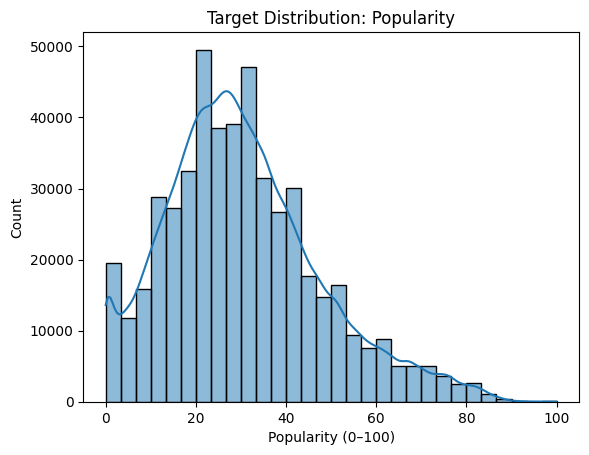

In [18]:
sns.histplot(df['Popularity'], bins=30, kde=True)
plt.title("Target Distribution: Popularity")
plt.xlabel("Popularity (0–100)")
plt.ylabel("Count")
plt.show()

The chart above shows us just how unlikely it is to make a song popular > 70.

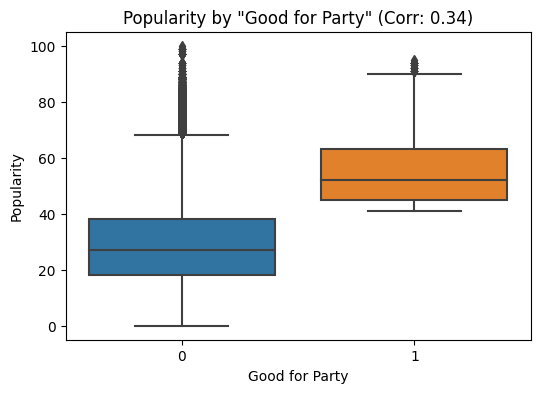

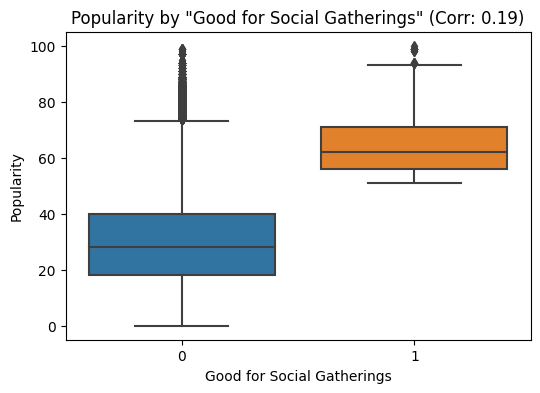

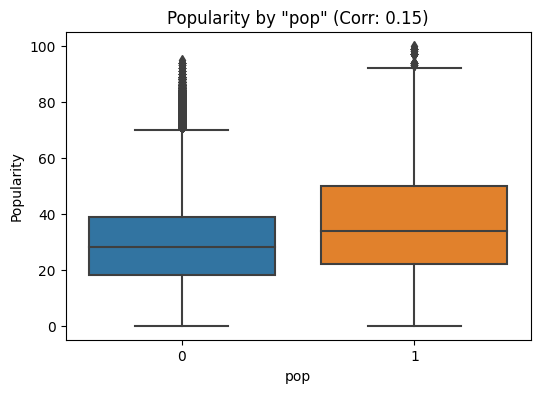

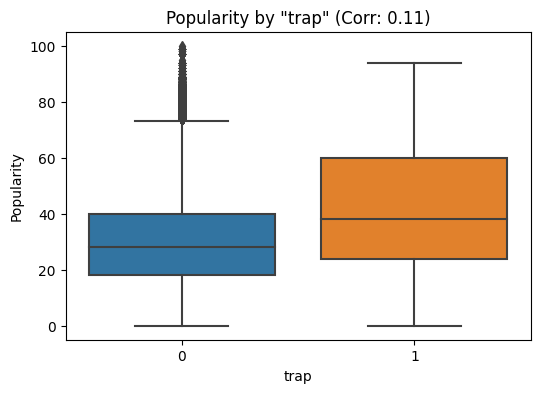

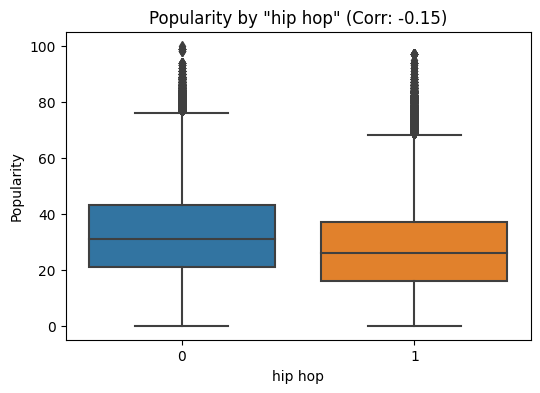

In [19]:
#compare binary features to get a boxplot
# Identify binary columns
binary_cols = [col for col in df.columns if df[col].nunique() == 2 and col != 'explicit']

# Compute correlations
corrs = df[binary_cols + ['Popularity']].corr()['Popularity'].drop('Popularity')

# Keep meaningful correlation
relevant_binary = corrs[abs(corrs) > 0.1].sort_values(ascending=False)

# Step 4: Plot boxplots
for col in relevant_binary.index:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col, y='Popularity')
    plt.title(f'Popularity by "{col}" (Corr: {corrs[col]:.2f})')
    plt.show()



It looks like good for party and good for social gatherings fall as higher than average popularity, which we'll track later on.

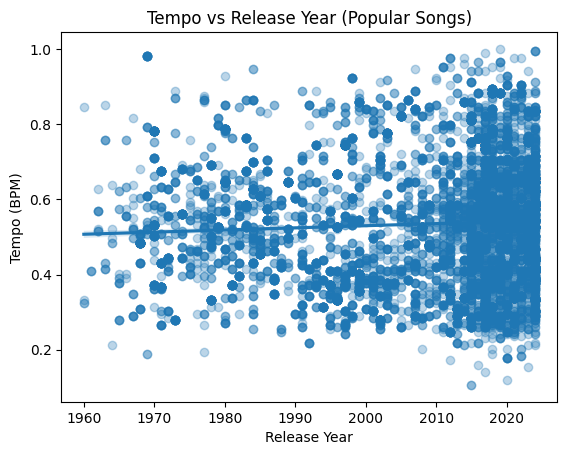

In [20]:
# Filter for popular songs and valid release years
popular_songs = df[(df['Popularity'] >= 70) & (df['release_year'] >= 0)]

# Scatterplot
sns.regplot(data=popular_songs, x='release_year', y='Tempo', scatter_kws={'alpha': 0.3})
plt.title("Tempo vs Release Year (Popular Songs)")
plt.xlabel("Release Year")
plt.ylabel("Tempo (BPM)")
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


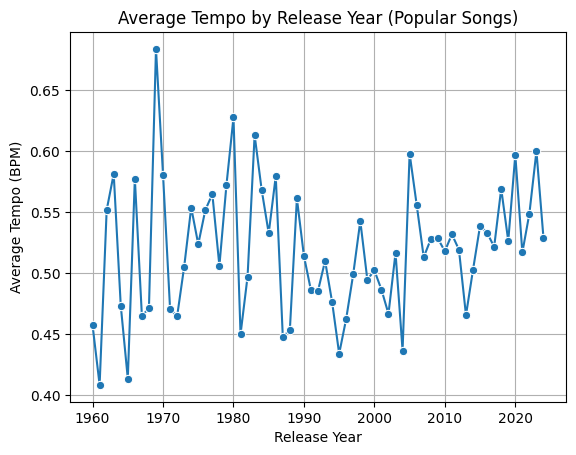

In [22]:
# Group by release year and calculate average tempo
yearly_avg = popular_songs.groupby('release_year')['Tempo'].mean().reset_index()

# Plot
sns.lineplot(data=yearly_avg, x='release_year', y='Tempo', marker='o')
plt.title("Average Tempo by Release Year (Popular Songs)")
plt.xlabel("Release Year")
plt.ylabel("Average Tempo (BPM)")
plt.grid(True)
plt.show()


Graph plotting popular songs, showing year vs BPM

['emotion_Love', 'emotion_True', 'emotion_anger', 'emotion_angry', 'emotion_confusion', 'emotion_fear', 'emotion_interest', 'emotion_joy', 'emotion_love', 'emotion_pink', 'emotion_sadness', 'emotion_surprise', 'emotion_thirst']


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


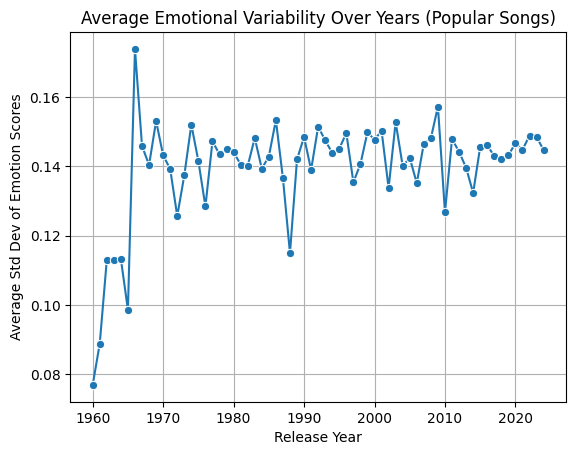

In [23]:
emotion_cols = [col for col in popular_songs.columns if col.startswith('emotion_')]

print(emotion_cols)

# std dev
emotion_variability = popular_songs.groupby('release_year')[emotion_cols].std()
emotion_variability['Mean_Emotion_STD'] = emotion_variability.mean(axis=1)  # average variability across emotions

sns.lineplot(data=emotion_variability, x=emotion_variability.index, y='Mean_Emotion_STD', marker='o')
plt.title("Average Emotional Variability Over Years (Popular Songs)")
plt.xlabel("Release Year")
plt.ylabel("Average Std Dev of Emotion Scores")
plt.grid(True)
plt.show()

Analyzing songs by year to get the standard deviation of each emotion within that year. (how much emotion varied among popular songs)

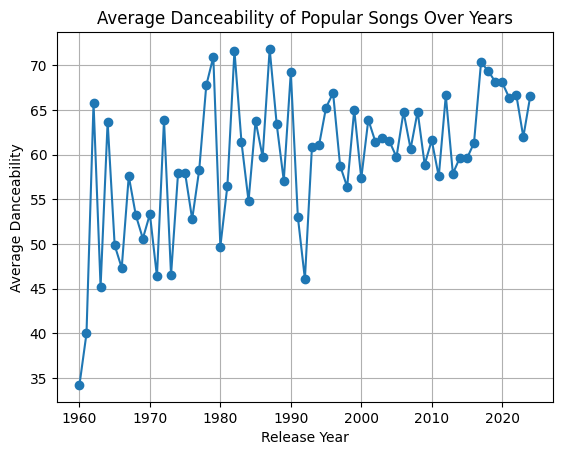

In [24]:
danceability_by_year = popular_songs.groupby('release_year')['Danceability'].mean()

# Plot the result
danceability_by_year.plot(marker='o')
plt.title("Average Danceability of Popular Songs Over Years")
plt.xlabel("Release Year")
plt.ylabel("Average Danceability")
plt.grid(True)
plt.show()

Now that all of our data has been converted to usable types, we can start to split the dataset and test

In [53]:
X = df.drop(columns='Popularity')
y = df['Popularity']

print(f"Number of features: {X_train.shape[1]}")

#train on 80% of data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Number of features: 147


In [26]:
from sklearn.ensemble import RandomForestRegressor

# model = RandomForestRegressor(n_estimators=100, random_state=42)
# model.fit(X_train, y_train)


model = RandomForestRegressor(
    n_estimators=20,     # Fewer trees = faster
    max_depth=10,        # Limit depth = fewer node splits
    n_jobs=-1,           # Use all CPU cores
    random_state=42
)
# model.fit(X_train, y_train)

# train on a sample first
X_sample = X_train.sample(50000, random_state=42)
y_sample = y_train.loc[X_sample.index]

model.fit(X_sample, y_sample)

RandomForestRegressor(max_depth=10, n_estimators=20, n_jobs=-1, random_state=42)

In [27]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R² score: {r2:.2f}")

#first scores using 50000 samples

# n_estimators=20,     # Fewer trees = faster
#     max_depth=10,        # Limit depth = fewer node splits
#     n_jobs=-1,           # Use all CPU cores
#     random_state=42


#RMSE: 14.56
#R² score: 0.28


#second time with all the rows, but still with the same max depth, estimators, jobs, and random state
# RMSE: 14.52
# R² score: 0.28

RMSE: 14.57
R² score: 0.28


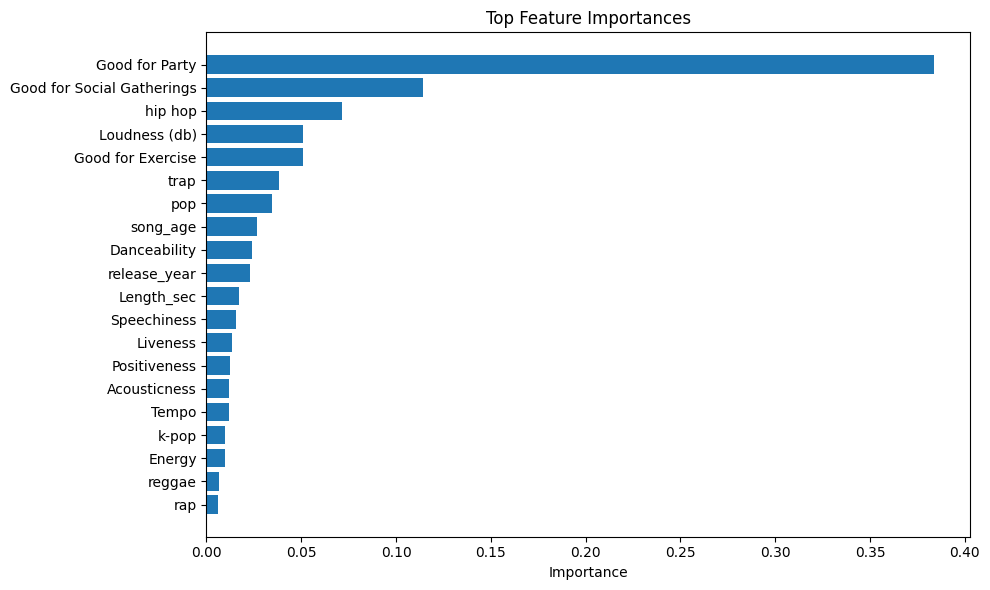

In [29]:
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

N = 20  # Top N features
top_importances = importances.head(N)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(range(N), top_importances['importance'][::-1], align='center')  # reverse for better ordering
plt.yticks(range(N), top_importances['feature'][::-1])
plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

After running it twice with different sample sizes, let's test different hyper parameters

In [30]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(65, 75),
    'max_depth': [60, 70],
    'min_samples_split': randint(2, 4),
    'min_samples_leaf': randint(1, 2),
    'max_features': ['sqrt']
}

model = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=5,              # combinations
    cv=4,                   # cross-validation
    scoring='r2',           # Optimize for R² score
    n_jobs=-1,              # Use all cpu cores
    verbose=1,
    random_state=42
)

X_sample = X_train.sample(50000, random_state=42)
y_sample = y_train.loc[X_sample.index]

# Fit the search
random_search.fit(X_sample, y_sample)

# Show the best parameters and score
print("Best hyperparameters:", random_search.best_params_)
print("Best CV R² score:", random_search.best_score_)

Fitting 4 folds for each of 5 candidates, totalling 20 fits
Best hyperparameters: {'max_depth': 70, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 71}
Best CV R² score: 0.3519688992827238


Best parameters for random forests

with 50,000 samples, so far these are the best hyperparameters:

Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best hyperparameters: {'max_depth': 40, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 70}
Best CV R² score: 0.30835031105145155

Second time
Best hyperparameters: {'max_depth': 60, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 68}
Best CV R² score: 0.32403770099612306

Third time
Best hyperparameters: {'max_depth': 75, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 78}
Best CV R² score: 0.32547949293173783


Changed folds and candidates:

Fitting 4 folds for each of 7 candidates, totalling 28 fits
Best hyperparameters: {'max_depth': 75, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 70}
Best CV R² score: 0.34798680987905395

Fitting 4 folds for each of 5 candidates, totalling 20 fits
Best hyperparameters: {'max_depth': 70, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 71}
Best CV R² score: 0.3528038302065678

Now that I have better hyper parameters, let's try plugging these in to the whole model!

In [31]:
final_model = RandomForestRegressor(
    n_estimators=75,
    max_depth=70,
    min_samples_split=4,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Train on full training set
final_model.fit(X_train, y_train)

# Predict on test set
y_pred = final_model.predict(X_test)

# Evaluate
from sklearn.metrics import mean_squared_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"Final RMSE: {rmse:.2f}")
print(f"Final R² score: {r2:.3f}")

Final RMSE: 12.12
Final R² score: 0.502


Wow! The final R² score went up significantly. Now using the whole dataset with the best hyperparameters yield these results:

Final RMSE: 12.03
Final R² score: 0.509

Going from R² of 0.28 to 0.51 is a significant increase. We also managed to reduce the RMSE from 14.52 to 12.03

In [32]:
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100  # Convert to %

print(f"Final MAE: {mae:.2f}")
print(f"Final MAPE: {mape:.2f}%")

Final MAE: 9.31
Final MAPE: 193782165418042176.00%


Im getting absurd MAPE, this might be due to some rows being 0.

In [33]:
# Convert to numpy arrays
y_test_np = np.array(y_test)
y_pred_np = np.array(y_pred)

# Filter out zero values
non_zero_mask = y_test_np != 0
y_test_nonzero = y_test_np[non_zero_mask]
y_pred_nonzero = y_pred_np[non_zero_mask]

mae = mean_absolute_error(y_test_np, y_pred_np)
mape = mean_absolute_percentage_error(y_test_nonzero, y_pred_nonzero) * 100  # in %
print(f"Final MAE: {mae:.2f}")
print(f"Final MAPE: {mape:.2f}%")

Final MAE: 9.31
Final MAPE: 76.49%


MAE: 9.31 tells is the average absolute error, which makes it more robust to outliers than RMSE

MAPE: on average predictions are 76.49% off from actual values, taking into account that its punishing smaller errors.

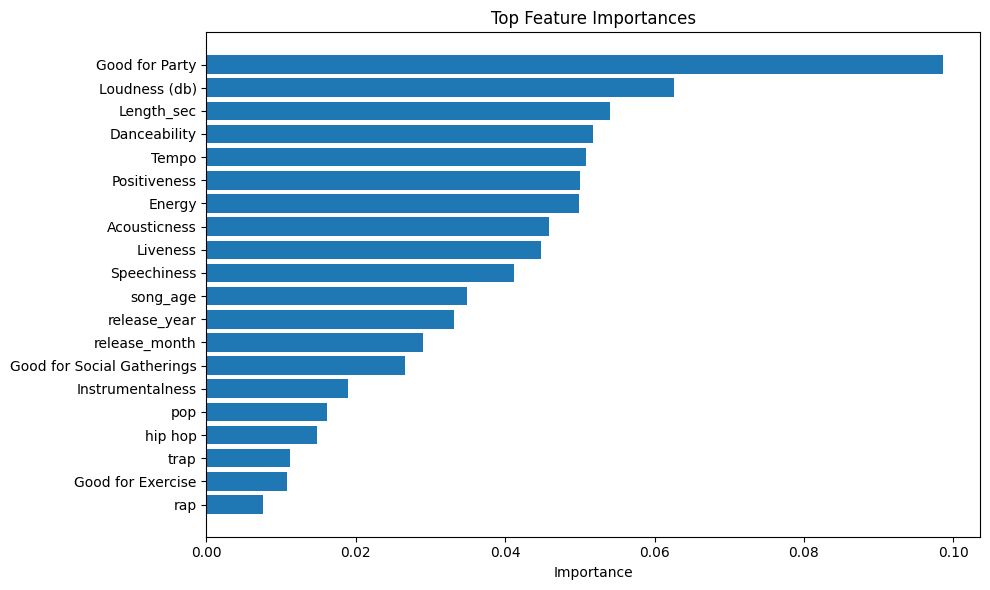

In [34]:
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': final_model.feature_importances_
}).sort_values(by='importance', ascending=False)

N = 20  # Top N features
top_importances = importances.head(N)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(range(N), top_importances['importance'][::-1], align='center')  # reverse for better ordering
plt.yticks(range(N), top_importances['feature'][::-1])
plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

As we can see, in the earlier model we had less samples ~50,000, which made the importance of features higher.

After using the entire dataset ~400,000 samples, we get a more accurate description of feature importance.

After seeing this, I would like to remove unimportant features and see if that improves the model's RMSE.

In [36]:
# Filter features by importance threshold
threshold = 0.01
important_features = importances[importances['importance'] > threshold]['feature'].tolist()

print(f"Keeping {len(important_features)} of {X_train.shape[1]} features")

Keeping 19 of 147 features


In [41]:
X_train_reduced = X_train[important_features]
X_test_reduced = X_test[important_features]

# Retrain model on reduced feature set
reduced_model = RandomForestRegressor(
    n_estimators=75,
    max_depth=70,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

reduced_model.fit(X_train_reduced, y_train)

RandomForestRegressor(max_depth=70, max_features='sqrt', n_estimators=75,
                      n_jobs=-1, random_state=42)

In [42]:
# STEP 5: Predict and evaluate
y_pred_reduced = reduced_model.predict(X_test_reduced)

rmse_reduced = mean_squared_error(y_test, y_pred_reduced, squared=False)
r2_reduced = r2_score(y_test, y_pred_reduced)

print(f"Reduced RMSE: {rmse_reduced:.2f}")
print(f"Reduced R² score: {r2_reduced:.3f}")

Reduced RMSE: 12.27
Reduced R² score: 0.489


It looks like by removing unimportant features the model didn't really improve, as a matter of fact it got a little worse
now:
Reduced RMSE: 12.27
Reduced R² score: 0.489

before:
Final RMSE: 12.03
Final R² score: 0.509

Let's also try tuning the model by using bigger dept and n_estimators

In [43]:
param_dist = {
    'n_estimators': randint(50, 150),
    'max_depth': [60, 80, 100],
    'min_samples_split': randint(2, 6),
    'min_samples_leaf': randint(1, 4),
    'max_features': ['sqrt']
}

reduced_model = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=reduced_model,
    param_distributions=param_dist,
    n_iter=5,              # combinations
    cv=3,                   # cross-validation
    scoring='r2',           # Optimize for R² score
    n_jobs=-1,              # Use all cpu cores
    verbose=1,
    random_state=42
)

X_sample = X_train_reduced.sample(50000, random_state=42)
y_sample = y_train.loc[X_sample.index]

# Fit the search
random_search.fit(X_sample, y_sample)

# Show the best parameters and score
print("Best hyperparameters:", random_search.best_params_)
print("Best CV R² score:", random_search.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best hyperparameters: {'max_depth': 60, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 132}
Best CV R² score: 0.3343669355193555


Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best hyperparameters: {'max_depth': 60, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 132}
Best CV R² score: 0.33324511089330655

Best hyperparameters: {'max_depth': 60, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 132}
Best CV R² score: 0.33324511089330655

Best hyperparameters: {'max_depth': 60, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 132}
Best CV R² score: 0.3343669355193555

In [46]:
final_model = RandomForestRegressor(
    n_estimators=132,
    max_depth=60,
    min_samples_split=4,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_reduced, y_train)

y_pred = final_model.predict(X_test_reduced)

rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"Final RMSE: {rmse:.2f}")
print(f"Final R² score: {r2:.3f}")

Final RMSE: 12.27
Final R² score: 0.490


The final scores of the new model with reduced features are:

Final RMSE: 12.27
Final R² score: 0.489

In [ ]:
feature_names = X_train.columns.tolist()
print(feature_names)

Let's see if we can get new patterns in the data by feature engineering some columns.

Positivity and Danceability are both high on the importance list, it might be worth combining.
Something being acoustic and having energy might indicate uniqueness in a song.
Tempo and song length might indicate a particular metric to see how people relate to a certain speed over time.
Loudness is already perceived as a good thing for music, if combined with speechiness it might give us insight whether people like to have something more freeform, often a good sign of rap, but also it's a break from a song pattern.
Instrumentalness and energy would be good to have to separate how ambient vs aggressive something is.

In [47]:
epsilon = 1e-5  # to prevent division by zero

df['dance_positiveness_interaction'] = df['Danceability'] * df['Positiveness']
df['acoustic_energy_ratio'] = df['Acousticness'] / (df['Energy'] + epsilon)
df['tempo_length'] = df['Tempo'] * df['Length_sec']
df['spoken_loudness'] = df['Speechiness'] * df['Loudness (db)']
df['inst_energy'] = df['Instrumentalness'] * df['Energy']

In [48]:
engineered_cols = [
    'dance_positiveness_interaction',
    'acoustic_energy_ratio',
    'tempo_length',
    'spoken_loudness',
    'inst_energy'
]

new_features = X_train_reduced.columns.tolist() + engineered_cols

X_train_updated = df.loc[X_train_reduced.index, new_features]
X_test_updated = df.loc[X_test_reduced.index, new_features]

new_model = RandomForestRegressor(
    n_estimators=132,
    max_depth=60,
    min_samples_split=4,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

new_model.fit(X_train_updated, y_train)
y_pred = new_model.predict(X_test_updated)

# Evaluate
from sklearn.metrics import mean_squared_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"Final RMSE: {rmse:.2f}")
print(f"Final R² score: {r2:.3f}")

# Feature names used in training
print("Features used:")
print(X_train_updated.columns.tolist())

Final RMSE: 12.31
Final R² score: 0.486
Features used:
['Good for Party', 'Loudness (db)', 'Length_sec', 'Danceability', 'Tempo', 'Positiveness', 'Energy', 'Acousticness', 'Liveness', 'Speechiness', 'song_age', 'release_year', 'release_month', 'Good for Social Gatherings', 'Instrumentalness', 'pop', 'hip hop', 'trap', 'Good for Exercise', 'dance_positiveness_interaction', 'acoustic_energy_ratio', 'tempo_length', 'spoken_loudness', 'inst_energy']


Results:
Final RMSE: 12.31
Final R² score: 0.486

This suggests that the new features we added didn't provide enough useful information vs the noise/multicollinearity we introduced into the model.

In [52]:
# Build feature importance DataFrame
importances = pd.DataFrame({
    'feature': X_train_updated.columns,
    'importance': new_model.feature_importances_
}).sort_values(by='importance', ascending=False)

# Display results
print("Top 10 most important features:")
print(importances.head(10))

print("\nBottom 10 least important features:")
print(importances.tail(10))

Top 10 most important features:
                           feature  importance
0                   Good for Party    0.101499
1                    Loudness (db)    0.068687
22                 spoken_loudness    0.061360
19  dance_positiveness_interaction    0.058381
21                    tempo_length    0.058139
2                       Length_sec    0.056896
4                            Tempo    0.053754
3                     Danceability    0.052510
20           acoustic_energy_ratio    0.051479
6                           Energy    0.050332

Bottom 10 least important features:
                       feature  importance
9                  Speechiness    0.032893
11                release_year    0.031598
13  Good for Social Gatherings    0.030479
12               release_month    0.028705
16                     hip hop    0.018216
23                 inst_energy    0.016853
15                         pop    0.016215
14            Instrumentalness    0.015107
17                        t

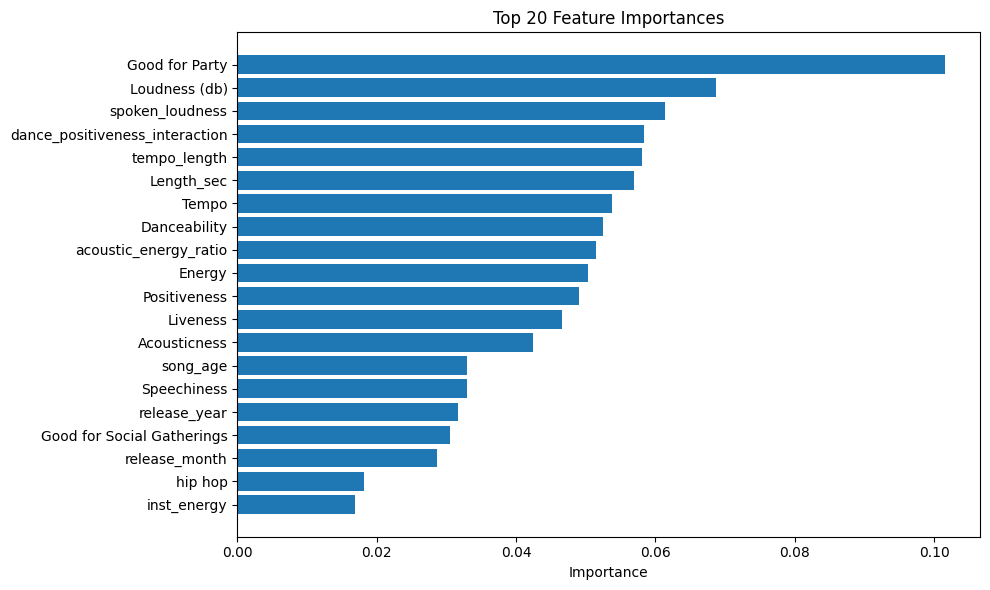

In [50]:
N = 20
top_importances = importances.head(N)

plt.figure(figsize=(10, 6))
plt.barh(top_importances['feature'][::-1], top_importances['importance'][::-1])  # reverse for top-down
plt.xlabel('Importance')
plt.title(f'Top {N} Feature Importances')
plt.tight_layout()
plt.show()


In [51]:

importances = pd.DataFrame({
    'feature': X_train_updated.columns,
    'importance': new_model.feature_importances_
}).sort_values(by='importance', ascending=False)

# low-importance features
low_importance_features = importances[importances['importance'] < 0.02]['feature'].tolist()

# Prune
X_train_pruned = X_train_updated.drop(columns=low_importance_features)
X_test_pruned = X_test_updated.drop(columns=low_importance_features)

print(f"Removed {len(low_importance_features)} low-importance features.")
print(f"Remaining features: {X_train_pruned.shape[1]}")

# Retrain
pruned_model = RandomForestRegressor(
    n_estimators=132,
    max_depth=60,
    min_samples_split=4,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

pruned_model.fit(X_train_pruned, y_train)
y_pred_pruned = pruned_model.predict(X_test_pruned)

# Evaluate
rmse_pruned = mean_squared_error(y_test, y_pred_pruned, squared=False)
r2_pruned = r2_score(y_test, y_pred_pruned)

print(f"\n🔍 Performance After Pruning")
print(f"Final RMSE: {rmse_pruned:.2f}")
print(f"Final R² score: {r2_pruned:.3f}")


Removed 6 low-importance features.
Remaining features: 18

🔍 Performance After Pruning
Final RMSE: 12.45
Final R² score: 0.475


Here is a summary of all the steps:
1. Load Data
2. Inspect Columns
3. Remove unwanted columns
4. Inspect column types
5. Transform column types into useful types/ Merge new columns that are very similar
6. Addressed null data cells
7.  Trained model (50k sample)
8. Assessed Results (RMSE, R_Squared, Important features)
9. Used randomSearchCV to optimize hyper parameters
10. Trained full model with hyper parameters
11.  Got new Results (RMSE, R_Squared, important features as well as MAE, and MAPE)
12. Removed 0 values, reassessed MAE, and MAPE
13.  Pruned based on feature importance
14. Retrained model, model got slightly worse
15. Recalculated hyper parameters
16. Retrained model, model stayed at around same RMSE and r squared.
18. Created new columns by combining features
19.  Trained new model, model stayed around the same RMSE and r squared even though the importance of the new features were high.
20. Removed features with < 0.02 importance.
21. Reassessed model with 18 features, RMSE and r squared were relatively equal to previous model.


Takeaways:
The biggest model improvement: 
* Tuning hyper parameters against the full data (more data + better hyper parameters = better model)
* Pruning and engineering: had marginal impact, although they did shift which features mattered most.

Graph:

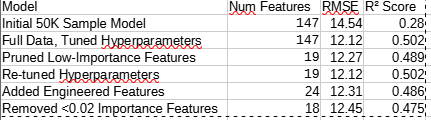


Things I would do differently:
* Track Feature Importance from the start to see how it compares to the end.
* Normalize/Transform skewed distributions of features
* Keep cross-validations consistent across all models
* Test each engineered feature instead of adding them all at the same time


Improvements past Random Forests:
Using a Gradient Boosting Model might outperform random forests by handling subtle patterns better.
Having more information about the instrumentation of a song, as well as the arrangement might help the model assess a song's popularity better.

Proving Hypothesis:
* Hypothesis 1: Older popular songs will have a lower BPM compared to newer popular songs.

* Wrong, more recent songs have less of a difference in BPM, but its not necessarily higher BPM

* Hypothesis 2: Newer songs will score higher in the danceability feature, - Yes, the trend of danceability seems to be going up with every year on average.

* While older popular songs will vary more in emotion - It looks like songs have more overall emotions in recent years
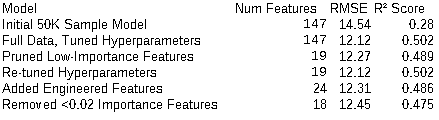
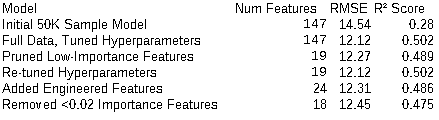
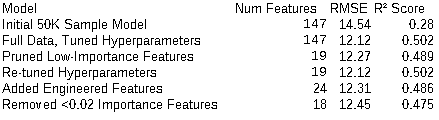
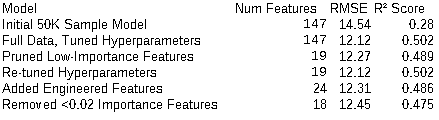